<a href="https://colab.research.google.com/github/rohanmyers/queue-viability/blob/main/notebooks/02_eda_queue_outcomes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q geopandas pyarrow openpyxl

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DRIVE_ROOT = Path("/content/drive/MyDrive/queue-viability")
RAW = DRIVE_ROOT / "data" / "raw"
FIGURES = DRIVE_ROOT / "reports" / "figures"
INTERIM = DRIVE_ROOT / "data" / "interim"

Mounted at /content/drive


In [ ]:
main = pd.read_excel(
    RAW / "lbnl_queued_up_2025.xlsx",
    sheet_name="03. Complete Queue Data",
    header=1  # use row index 1 (the second row) as the header
)
print(f"Main dataset: {main.shape}")
print(f"\nColumns:")
for c in main.columns:
    print(f"  {c}")

main.head(3)

Main dataset: (36441, 31)

Columns:
  q_id
  q_status
  q_date
  prop_date
  on_date
  wd_date
  ia_date
  IA_status_raw
  IA_status_clean
  county
  state
  county_state_pairs
  fips_codes
  poi_name
  region
  project_name
  utility
  entity
  developer
  cluster
  service
  project_type
  type1
  type2
  type3
  mw1
  mw2
  mw3
  type_clean
  q_year
  prop_year


,q_id,q_status,q_date,prop_date,on_date,wd_date,ia_date,IA_status_raw,IA_status_clean,county,...,project_type,type1,type2,type3,mw1,mw2,mw3,type_clean,q_year,prop_year
0,not assigned,withdrawn,43511.0,NaN,NaN,NaN,NaN,Withdrawn,Withdrawn,Coconino,...,Generation,Solar,NaN,NaN,20.0,NaN,NaN,Solar,2019.0,NaN
1,Q007 - 061,operational,38497.0,39539.0,NaN,NaN,NaN,In-Service,Operational,Navajo,...,Generation,Other,NaN,NaN,24.0,NaN,NaN,Other,2005.0,2008.0
2,Q044a.,withdrawn,39597.0,40909.0,NaN,NaN,NaN,Withdrawn,Withdrawn,Yuma,...,Generation,Solar,NaN,NaN,900.0,NaN,NaN,Solar,2008.0,2012.0


In [ ]:
print("=== Q_STATUS DISTRIBUTION ===")
print(main['q_status'].value_counts(dropna=False))

print("\n=== TRAINABLE ROWS ===")
operational = (main['q_status'] == 'operational').sum()
withdrawn = (main['q_status'] == 'withdrawn').sum()
suspended = (main['q_status'] == 'suspended').sum()
active = (main['q_status'] == 'active').sum()
unknown = (main['q_status'] == 'unknown').sum()

print(f"Operational (Y=1):         {operational:>7,}")
print(f"Withdrawn (Y=0):           {withdrawn:>7,}")
print(f"Suspended (Y=0 candidate): {suspended:>7,}")
print(f"Active (to score later):   {active:>7,}")
print(f"Unknown (exclude):         {unknown:>7,}")

trainable = operational + withdrawn
print(f"\nTrainable rows: {trainable:,}")
print(f"Class balance: {operational/trainable:.1%} positive")

=== Q_STATUS DISTRIBUTION ===
q_status
withdrawn      20921
active         10538
operational     4432
suspended        546
unknown            4
Name: count, dtype: int64

=== TRAINABLE ROWS ===
Operational (Y=1):           4,432
Withdrawn (Y=0):            20,921
Suspended (Y=0 candidate):     546
Active (to score later):    10,538
Unknown (exclude):               4

Trainable rows: 25,353
Class balance: 17.5% positive


In [ ]:
# Keep only Generation + Surplus; drop Upgrade/Replacement
print("=== PROJECT TYPE ===")
print(main['project_type'].value_counts(dropna=False))

gen = main[main['project_type'].isin(['Generation', 'Surplus'])].copy()
print(f"\nAfter filtering to Generation+Surplus: {len(gen):,} rows")
print(f"\nq_status within generation:")
print(gen['q_status'].value_counts())

=== PROJECT TYPE ===
project_type
Generation     33454
NaN             2779
Surplus          112
Upgrade           81
Replacement       15
Name: count, dtype: int64

After filtering to Generation+Surplus: 33,566 rows

q_status within generation:
q_status
withdrawn      18840
active         10430
operational     3747
suspended        546
unknown            3
Name: count, dtype: int64


In [ ]:
print("=== REGIONS ===")
print(gen['region'].value_counts(dropna=False))

print("\n=== OPERATIONAL VS WITHDRAWN BY REGION ===")
region_crosstab = pd.crosstab(
    gen['region'],
    gen['q_status'],
    margins=True
)
print(region_crosstab)

=== REGIONS ===
region
PJM          8099
West         7647
Southeast    3893
MISO         3282
ERCOT        2582
CAISO        2534
SPP          2432
NYISO        1816
ISO-NE       1281
Name: count, dtype: int64

=== OPERATIONAL VS WITHDRAWN BY REGION ===
q_status   active  operational  suspended  unknown  withdrawn    All
region                                                              
CAISO         638          228          0        0       1668   2534
ERCOT        1672          298        156        0        456   2582
ISO-NE        399          219          0        0        663   1281
MISO         2153           84          0        0       1045   3282
NYISO         402          111          0        0       1303   1816
PJM          1942         1190        130        0       4837   8099
SPP           633          264          8        0       1527   2432
Southeast     974          415         34        0       2470   3893
West         1617          938        218        3     

In [ ]:
print("=== FUEL TYPE (type_clean) ===")
print(gen['type_clean'].value_counts(dropna=False))

print("\n=== COMPLETION RATE BY FUEL TYPE (trainable rows only) ===")
trainable_gen = gen[gen['q_status'].isin(['operational', 'withdrawn'])].copy()
trainable_gen['is_operational'] = (trainable_gen['q_status'] == 'operational').astype(int)

completion_by_fuel = (
    trainable_gen.groupby('type_clean')['is_operational']
    .agg(['mean', 'count'])
    .sort_values('count', ascending=False)
)
completion_by_fuel.columns = ['completion_rate', 'n']
print(completion_by_fuel)

=== FUEL TYPE (type_clean) ===
type_clean
Solar                           13270
Battery                          5354
Wind                             4926
Solar+Battery                    3569
Gas                              2945
Other                            1448
Hydro                             456
Coal                              303
Offshore Wind                     230
Geothermal                        158
Nuclear                           132
Gas+Oil                           110
Other Storage                      97
Wind+Battery                       96
Oil                                79
Diesel                             75
Other+Battery                      74
Solar+Wind+Battery                 66
Gas+Battery                        34
Solar+Wind                         28
Solar+Other                        25
Solar+Gas+Battery                  21
Solar+Gas                          14
Gas+Other                           9
Hydro+Battery                       7
Wind+Oth

In [ ]:
print("=== DATE FIELDS ===")
for col in ['q_date', 'prop_date', 'on_date', 'wd_date', 'ia_date']:
    print(f"\n{col}:")
    print(f"  dtype: {main[col].dtype}")
    print(f"  non-null: {main[col].notna().sum():,} / {len(main):,}")
    if main[col].notna().any():
        # Try to parse if not already datetime
        dates = pd.to_datetime(main[col], errors='coerce')
        print(f"  range: {dates.min()} to {dates.max()}")

=== DATE FIELDS ===

q_date:
  dtype: float64
  non-null: 35,834 / 36,441
  range: 1970-01-01 00:00:00.000025569 to 1970-01-01 00:00:00.000045657

prop_date:
  dtype: float64
  non-null: 29,029 / 36,441
  range: 1970-01-01 00:00:00.000002001 to 1970-01-01 00:00:00.000055153

on_date:
  dtype: float64
  non-null: 2,957 / 36,441
  range: 1970-01-01 00:00:00.000008825 to 1970-01-01 00:00:00.000045656

wd_date:
  dtype: float64
  non-null: 10,138 / 36,441
  range: 1970-01-01 00:00:00.000036337 to 1970-01-01 00:00:00.000045707

ia_date:
  dtype: float64
  non-null: 2,440 / 36,441
  range: 1970-01-01 00:00:00.000025569 to 1970-01-01 00:00:00.000045656


In [ ]:
print("=== Q_YEAR DISTRIBUTION ===")
print(gen['q_year'].value_counts().sort_index())

print("\n=== PROP_YEAR DISTRIBUTION ===")
print(gen['prop_year'].value_counts().sort_index().tail(20))

=== Q_YEAR DISTRIBUTION ===
q_year
1970.0     128
1997.0      16
1998.0      48
1999.0     173
2000.0     242
2001.0     424
2002.0     182
2003.0     211
2004.0     212
2005.0     379
2006.0     560
2007.0     831
2008.0    1005
2009.0     674
2010.0    1136
2011.0     895
2012.0     498
2013.0     551
2014.0     748
2015.0     993
2016.0    1464
2017.0    1820
2018.0    1976
2019.0    2322
2020.0    2617
2021.0    3560
2022.0    3514
2023.0    3333
2024.0    2465
Name: count, dtype: int64

=== PROP_YEAR DISTRIBUTION ===
prop_year
2018.0     646
2019.0     830
2020.0    1070
2021.0    1170
2022.0    1372
2023.0    2177
2024.0    2097
2025.0    2711
2026.0    2545
2027.0    2249
2028.0    1956
2029.0     575
2030.0     401
2031.0     178
2032.0      64
2033.0      48
2034.0      20
2035.0      12
2036.0       1
2047.0       1
Name: count, dtype: int64


In [ ]:
print("=== Q_YEAR DISTRIBUTION ===")
print(gen['q_year'].value_counts().sort_index())

print("\n=== PROP_YEAR DISTRIBUTION ===")
print(gen['prop_year'].value_counts().sort_index().tail(20))

=== Q_YEAR DISTRIBUTION ===
q_year
1970.0     128
1997.0      16
1998.0      48
1999.0     173
2000.0     242
2001.0     424
2002.0     182
2003.0     211
2004.0     212
2005.0     379
2006.0     560
2007.0     831
2008.0    1005
2009.0     674
2010.0    1136
2011.0     895
2012.0     498
2013.0     551
2014.0     748
2015.0     993
2016.0    1464
2017.0    1820
2018.0    1976
2019.0    2322
2020.0    2617
2021.0    3560
2022.0    3514
2023.0    3333
2024.0    2465
Name: count, dtype: int64

=== PROP_YEAR DISTRIBUTION ===
prop_year
2018.0     646
2019.0     830
2020.0    1070
2021.0    1170
2022.0    1372
2023.0    2177
2024.0    2097
2025.0    2711
2026.0    2545
2027.0    2249
2028.0    1956
2029.0     575
2030.0     401
2031.0     178
2032.0      64
2033.0      48
2034.0      20
2035.0      12
2036.0       1
2047.0       1
Name: count, dtype: int64


MW column null counts:
  mw1: 0
  mw2: 32,551
  mw3: 33,523


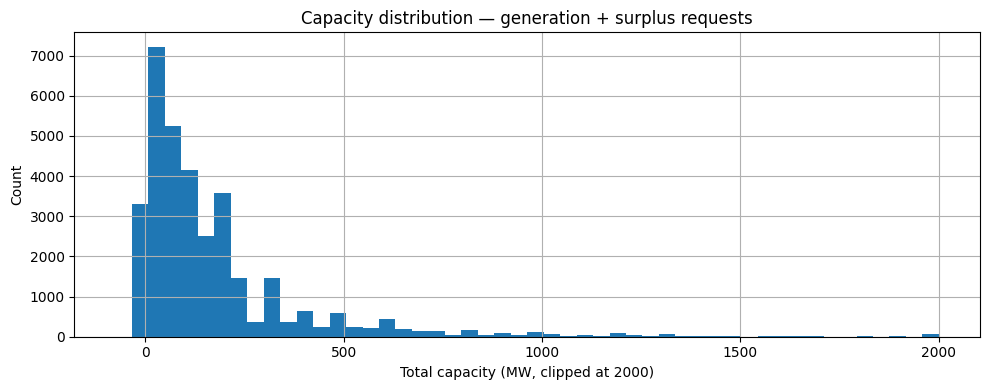


Median MW: 100.0
Mean MW: 174.7
Max MW: 16875.0


In [ ]:
import matplotlib.pyplot as plt

# mw1 is usually the primary capacity; check whether to sum mw1+mw2+mw3 or just use mw1
print("MW column null counts:")
print(f"  mw1: {gen['mw1'].isna().sum():,}")
print(f"  mw2: {gen['mw2'].isna().sum():,}")
print(f"  mw3: {gen['mw3'].isna().sum():,}")

# Approximate total capacity
gen['mw_total'] = gen[['mw1', 'mw2', 'mw3']].sum(axis=1, min_count=1)

fig, ax = plt.subplots(figsize=(10, 4))
gen['mw_total'].dropna().clip(upper=2000).hist(bins=50, ax=ax)
ax.set_xlabel("Total capacity (MW, clipped at 2000)")
ax.set_ylabel("Count")
ax.set_title("Capacity distribution — generation + surplus requests")
plt.tight_layout()
plt.savefig(FIGURES / "capacity_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"\nMedian MW: {gen['mw_total'].median():.1f}")
print(f"Mean MW: {gen['mw_total'].mean():.1f}")
print(f"Max MW: {gen['mw_total'].max():.1f}")

In [ ]:
print("=== TOP 20 DEVELOPERS BY REQUEST COUNT ===")
print(gen['developer'].value_counts().head(20))

print(f"\nUnique developers: {gen['developer'].nunique():,}")
print(f"Projects with missing developer: {gen['developer'].isna().sum():,}")

=== TOP 20 DEVELOPERS BY REQUEST COUNT ===
developer
FPL                                             373
Masked                                          233
PacifiCorp                                      189
Duke Energy Florida, LLC                        145
Duke Energy Progress, LLC                        70
PacifiCorp Commercial & Trading                  39
EDF Renewables Development, Inc.                 38
Third Party                                      34
RWE Solar Development, LLC                       30
ACE DevCo NC, LLC                                23
PacifiCorp Energy                                23
SCPSA                                            22
Nextera                                          22
Intermountain Power Agency                       21
sPower Development Company, LLC                  17
Emeren US, LLC                                   17
Duke Energy Progress LLC                         17
Community Offshore Wind, LLC                     16
Granada Sol

In [ ]:
trainable_gen = gen[gen['q_status'].isin(['operational', 'withdrawn'])].copy()
trainable_gen['is_operational'] = (trainable_gen['q_status'] == 'operational').astype(int)

by_year = trainable_gen.groupby('q_year').agg(
    n=('is_operational', 'size'),
    operational_rate=('is_operational', 'mean')
).tail(15)
print(by_year)

           n  operational_rate
q_year                        
2010.0  1127          0.181899
2011.0   878          0.157175
2012.0   482          0.271784
2013.0   535          0.302804
2014.0   725          0.257931
2015.0   929          0.227126
2016.0  1285          0.205447
2017.0  1520          0.183553
2018.0  1559          0.132136
2019.0  1621          0.136336
2020.0  1697          0.076016
2021.0  1912          0.024582
2022.0  1319          0.011372
2023.0  1233          0.050284
2024.0   337          0.008902


In [ ]:
gen['type_clean'] = gen['type_clean'].str.replace('\xa0', ' ', regex=False)
print("After cleaning:")
print(gen['type_clean'].value_counts().head(10))

After cleaning:
type_clean
Solar            13270
Battery           5354
Wind              4926
Solar+Battery     3569
Gas               2945
Other             1448
Hydro              456
Coal               303
Offshore Wind      230
Geothermal         158
Name: count, dtype: int64


In [ ]:
gen['q_id'] = gen['q_id'].astype(str)

for col in gen.select_dtypes(include='object').columns:
    types = gen[col].dropna().map(type).unique()
    if len(types) > 1:
        print(f"Mixed types in {col}: {types}")
        gen[col] = gen[col].astype(str)

Mixed types in IA_status_raw: [<class 'str'> <class 'int'>]
Mixed types in poi_name: [<class 'str'> <class 'float'> <class 'int'>]
Mixed types in project_name: [<class 'str'> <class 'int'>]
Mixed types in cluster: [<class 'int'> <class 'str'>]


In [ ]:
gen.to_parquet(INTERIM / "generation_queue.parquet", index=False)
print(f"Saved {len(gen):,} rows to {INTERIM / 'generation_queue.parquet'}")

Saved 33,566 rows to /content/drive/MyDrive/queue-viability/data/interim/generation_queue.parquet


In [ ]:
codebook = pd.read_excel(
    RAW / "lbnl_queued_up_2025.xlsx",
    sheet_name="04. Data Codebook"
)
codebook

,RETURN TO CONTENTS,Unnamed: 1
0,Field Name,Description
1,q_id,queue ID number
2,q_status,"current queue status (active, withdrawn, suspe..."
3,q_date,interconnection request date (date project ent...
4,prop_date,proposed online date from interconnection appl...
5,on_date,date project became operational (if applicable)
6,wd_date,date project withdrawn from queue (if applicable)
7,ia_date,date of signed interconnection agreement (if a...
8,IA_status_raw,interconnection study phase / status from queue
9,IA_status_clean,standardized interconnection study phase / status


In [ ]:
trainable_clean = gen[
    (gen['q_status'].isin(['operational', 'withdrawn'])) &
    (gen['q_year'] <= 2019)
]
clean_operational = (trainable_clean['q_status'] == 'operational').sum()
clean_withdrawn = (trainable_clean['q_status'] == 'withdrawn').sum()

print(f"Training set after 2019 cutoff:")
print(f"  Operational: {clean_operational:,}")
print(f"  Withdrawn: {clean_withdrawn:,}")
print(f"  Total: {len(trainable_clean):,}")
print(f"  Class balance: {clean_operational/len(trainable_clean):.1%}")

Training set after 2019 cutoff:
  Operational: 3,265
  Withdrawn: 12,397
  Total: 15,662
  Class balance: 20.8%


In [ ]:
# Recompute the post-cutoff training set numbers
trainable_clean = gen[
    (gen['q_status'].isin(['operational', 'withdrawn'])) &
    (gen['q_year'] <= 2019)
].copy()

clean_operational = (trainable_clean['q_status'] == 'operational').sum()
clean_withdrawn = (trainable_clean['q_status'] == 'withdrawn').sum()
clean_total = len(trainable_clean)

feasibility = f"""# Feasibility Assessment

## Dataset
- Source: LBNL Queued Up 2025 Edition, sheet `03. Complete Queue Data`
- Total rows: {len(main):,}
- Generation + Surplus rows: {len(gen):,}

## Label availability (generation only)
- Operational (Y=1): {(gen['q_status']=='operational').sum():,}
- Withdrawn (Y=0): {(gen['q_status']=='withdrawn').sum():,}
- Suspended: {(gen['q_status']=='suspended').sum():,}
- Active (to score): {(gen['q_status']=='active').sum():,}
- Raw trainable rows: {(gen['q_status'].isin(['operational','withdrawn'])).sum():,}

## Temporal label reliability
Operational rates by queue-entry year show steep drop after 2019:
- 2010-2019: 13-30% operational rates (mature outcomes)
- 2020: 7.6%
- 2021: 2.5%
- 2022: 1.1%
- 2024: 0.9%

Projects entering the queue after 2019 haven't had time to either complete or
formally withdraw, so their "withdrawn" labels are unreliable — a project still
in study phase is not the same as a project that failed.

## Training cutoff decision
**Use q_year <= 2019 for training.** Post-2019 requests held out for scoring only.

- Clean training set (2010-2019): {clean_total:,} rows
  - Operational (Y=1): {clean_operational:,}
  - Withdrawn (Y=0): {clean_withdrawn:,}
  - Class balance: {clean_operational/clean_total:.1%} positive

## Regional coverage
{gen['region'].value_counts().to_string()}

## Fuel type coverage (top 10 after Unicode cleanup)
{gen['type_clean'].value_counts().head(10).to_string()}

## Baseline completion rate to beat
- Overall (full trainable set): 16.6%
- 2010-2019 cohort only: {clean_operational/clean_total:.1%}

## Go/no-go decision
[x] Proceed with Path A: generation queue viability
- Scope: predict whether a queued generation request will reach commercial operation
- Training set: 2010-2019 queue entries only
- Scoring set: 2020+ requests (including all ~10,430 active projects)
- Features planned: capacity, fuel type, region, utility, developer track record,
  queue vintage, IA_status_clean (ordinal study phase), geographic features
  (substation distance from HIFLD), retail electricity price (EIA 861)
- Framing: motivated by FERC Order 2023 interconnection backlog and related
  data center / phantom-load concerns
"""

memo_path = DRIVE_ROOT / "reports" / "feasibility.md"
memo_path.write_text(feasibility)
print(f"Wrote {memo_path}")
print("\n" + feasibility)

Wrote /content/drive/MyDrive/data-center-queue-viability/reports/feasibility.md

# Feasibility Assessment

## Dataset
- Source: LBNL Queued Up 2025 Edition, sheet `03. Complete Queue Data`
- Total rows: 36,441
- Generation + Surplus rows: 33,566

## Label availability (generation only)
- Operational (Y=1): 3,747
- Withdrawn (Y=0): 18,840
- Suspended: 546
- Active (to score): 10,430
- Raw trainable rows: 22,587

## Temporal label reliability
Operational rates by queue-entry year show steep drop after 2019:
- 2010-2019: 13-30% operational rates (mature outcomes)
- 2020: 7.6%
- 2021: 2.5%
- 2022: 1.1%
- 2024: 0.9%

Projects entering the queue after 2019 haven't had time to either complete or
formally withdraw, so their "withdrawn" labels are unreliable — a project still
in study phase is not the same as a project that failed.

## Training cutoff decision
**Use q_year <= 2019 for training.** Post-2019 requests held out for scoring only.

- Clean training set (2010-2019): 15,662 rows
  - Op